# 05 — EAD Model (Exposure at Default)

**Objective:** Estimate the fraction of the funded loan amount still outstanding at default (`ead_pct`, bounded [0, 1]).

**Input:** `df_model_raw.csv` — full raw dataset. We filter to defaulted loans, apply preprocessing, and create the EAD target.

**Finding:** Origination-time features have near-zero correlation with EAD — all regression models (Linear, RF, XGBoost, LightGBM) produced negative R². EAD is driven by *when* during the loan term default occurs, which is unpredictable at origination.

**Approach:** Mean EAD by term bucket — industry-standard for unsecured consumer loans. Simple, interpretable, and no worse than complex models on this data.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import xgboost as xgb
import lightgbm as lgb
import json
import time
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## 1. Load Data & Train/Test Split

In [14]:
# Load raw data — need full features + leakage columns for EAD target
df = pd.read_csv('../data/df_model_raw.csv', low_memory=False)

# Parse issue date and create targets BEFORE dropping leakage columns
df['issue_d_parsed'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
df['issue_year'] = df['issue_d_parsed'].dt.year
df['issue_month'] = df['issue_d_parsed'].dt.month

# Filter to defaults only, exclude 2018 (right-censored)
df = df[(df['default'] == 1) & (df['issue_year'] <= 2017)].copy()

# EAD target: outstanding balance as fraction of funded amount
df['ead_pct'] = ((df['funded_amnt'] - df['total_rec_prncp']) / df['funded_amnt']).clip(0, 1)
# LGD target (carried through for notebook 06)
df['lgd'] = (1 - (df['recoveries'] / df['funded_amnt']).clip(0, 1)).clip(0, 1)

# --- Preprocessing pipeline (mirrors notebook 02) ---
# Drop leakage, ID/text, redundant, high-missing, single-value columns
drop_cols = [
    # Leakage (post-outcome)
    'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
    'recoveries', 'collection_recovery_fee', 'last_pymnt_d',
    'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
    'last_fico_range_high', 'last_fico_range_low',
    'debt_settlement_flag', 'debt_settlement_flag_date',
    'settlement_status', 'settlement_date', 'settlement_amount',
    'settlement_percentage', 'settlement_term',
    'hardship_flag', 'hardship_type', 'hardship_reason',
    'hardship_status', 'deferral_term', 'hardship_amount',
    'hardship_start_date', 'hardship_end_date',
    'payment_plan_start_date', 'hardship_length', 'hardship_dpd',
    'hardship_loan_status', 'orig_projected_additional_accrued_interest',
    'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
    'disbursement_method',
    # ID / text / URL
    'id', 'member_id', 'url', 'desc', 'emp_title', 'title', 'zip_code',
    # Redundant
    'funded_amnt', 'funded_amnt_inv', 'grade', 'loan_status',
    # EDA temp
    'fico_avg', 'fico_bin', 'issue_date',
]
single_val = [c for c in df.columns if df[c].nunique() <= 1]
high_miss = df.columns[df.isnull().mean() > 0.5].tolist()
drop_cols = drop_cols + single_val + high_miss

keep = {'default', 'ead_pct', 'lgd', 'issue_year', 'issue_month'}
drop_cols = list(set(c for c in drop_cols if c in df.columns and c not in keep))
df.drop(columns=drop_cols, inplace=True)

# Parse term
df['term'] = df['term'].str.strip().str.replace(' months', '', regex=False).astype(int)

# Parse emp_length
emp_map = {'< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
           '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
           '8 years': 8, '9 years': 9, '10+ years': 10}
df['emp_length'] = df['emp_length'].map(emp_map)

# Credit history length
ecl = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y', errors='coerce')
df['credit_history_months'] = (
    (df['issue_d_parsed'].dt.year - ecl.dt.year) * 12 +
    (df['issue_d_parsed'].dt.month - ecl.dt.month)
)
df.drop(columns=['earliest_cr_line', 'issue_d', 'issue_d_parsed'], inplace=True, errors='ignore')

# Home ownership: merge rare categories
df['home_ownership'] = df['home_ownership'].replace({'NONE': 'OTHER', 'ANY': 'OTHER'})

# Application type — drop (was converted to is_joint_app in nb02, then dropped in nb03 feature selection)
df.drop(columns=['application_type'], inplace=True, errors='ignore')

# Initial list status → binary
df['initial_list_status'] = (df['initial_list_status'] == 'f').astype(int)

# FICO score
df['fico_score'] = (df['fico_range_low'] + df['fico_range_high']) / 2
df.drop(columns=['fico_range_low', 'fico_range_high'], inplace=True)

# Median imputation for all numeric missing values
for col in df.select_dtypes(include=[np.number]).columns:
    if df[col].isnull().any() and col not in keep:
        df[col].fillna(df[col].median(), inplace=True)

# Outlier winsorization at 99.5th percentile
for col in ['annual_inc', 'dti', 'revol_bal', 'revol_util', 'open_acc', 'total_acc']:
    if col in df.columns:
        df[col] = df[col].clip(upper=df[col].quantile(0.995))
if 'revol_util' in df.columns:
    df['revol_util'] = df['revol_util'].clip(upper=100)
if 'dti' in df.columns:
    df['dti'] = df['dti'].clip(lower=0)

print(f"Defaulted loans: {df.shape}")
print(f"EAD% stats:")
print(df['ead_pct'].describe())
print(f"Vintage distribution:")
print(df['issue_year'].value_counts().sort_index())

cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")

Defaulted loans: (260486, 68)
EAD% stats:
count    260486.000000
mean          0.689543
std           0.218020
min           0.000000
25%           0.558138
50%           0.737651
75%           0.863097
max           1.000000
Name: ead_pct, dtype: float64
Vintage distribution:
issue_year
2007      158
2008      496
2009      723
2010     1757
2011     3297
2012     8644
2013    21024
2014    41162
2015    75804
2016    68252
2017    39169
Name: count, dtype: int64
Categorical columns (5): ['sub_grade', 'home_ownership', 'verification_status', 'purpose', 'addr_state']


In [15]:
# Vintage-based split (same as PD model)
train = df[df['issue_year'] <= 2015].copy()
test = df[df['issue_year'].between(2016, 2017)].copy()

print(f"Train (2007-2015): {train.shape}  |  EAD% mean: {train['ead_pct'].mean():.4f}")
print(f"Test  (2016-2017): {test.shape}  |  EAD% mean: {test['ead_pct'].mean():.4f}")

Train (2007-2015): (153065, 68)  |  EAD% mean: 0.6475
Test  (2016-2017): (107421, 68)  |  EAD% mean: 0.7495


## 2. Feature Engineering

Same pipeline as notebooks 02–03: ordinal encoding for sub_grade, one-hot for home/verif/purpose, target encoding for state (using mean EAD% instead of default rate). Financial ratios added from raw credit bureau fields.

In [7]:
# --- Ordinal encoding: sub_grade ---
grades = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
sub_grades = [f'{g}{n}' for g in grades for n in range(1, 6)]
sub_grade_map = {sg: i for i, sg in enumerate(sub_grades)}

for d in [train, test]:
    d['sub_grade_encoded'] = d['sub_grade'].map(sub_grade_map)

# --- One-hot encoding ---
for col, prefix in [('home_ownership', 'home'),
                     ('verification_status', 'verif'),
                     ('purpose', 'purpose')]:
    train = pd.get_dummies(train, columns=[col], prefix=prefix, drop_first=True)
    test = pd.get_dummies(test, columns=[col], prefix=prefix, drop_first=True)

# Align columns
for col in train.columns:
    if col not in test.columns:
        test[col] = 0
for col in test.columns:
    if col not in train.columns:
        train[col] = 0

# --- State target encoding (using EAD% as target) ---
global_ead = train['ead_pct'].mean()
smoothing = 100
state_stats = train.groupby('addr_state')['ead_pct'].agg(['mean', 'count'])
state_stats['smoothed'] = (
    (state_stats['count'] * state_stats['mean'] + smoothing * global_ead) /
    (state_stats['count'] + smoothing)
)
state_map = state_stats['smoothed'].to_dict()

train['state_ead_rate'] = train['addr_state'].map(state_map)
test['state_ead_rate'] = test['addr_state'].map(state_map)
test['state_ead_rate'].fillna(global_ead, inplace=True)

# Drop original categoricals
train.drop(columns=['sub_grade', 'addr_state'], inplace=True, errors='ignore')
test.drop(columns=['sub_grade', 'addr_state'], inplace=True, errors='ignore')

print(f"After encoding — Train: {train.shape}, Test: {test.shape}")

After encoding — Train: (153065, 83), Test: (107421, 83)


In [8]:
# --- Financial ratios ---
def create_features(d):
    d['loan_to_income'] = d['loan_amnt'] / (d['annual_inc'] + 1)
    d['installment_to_income'] = d['installment'] / (d['annual_inc'] / 12 + 1)
    d['revol_bal_to_income'] = d['revol_bal'] / (d['annual_inc'] + 1)
    d['available_credit'] = d['total_rev_hi_lim'] - d['revol_bal']
    d['available_credit_pct'] = d['available_credit'] / (d['total_rev_hi_lim'] + 1)
    d['active_ratio'] = d['open_acc'] / (d['total_acc'] + 1)
    d['delinq_per_account'] = d['delinq_2yrs'] / (d['total_acc'] + 1)
    d['pub_rec_per_account'] = d['pub_rec'] / (d['total_acc'] + 1)
    d['installment_pct_of_loan'] = d['installment'] / (d['loan_amnt'] + 1)
    d['accounts_per_year'] = d['total_acc'] / (d['credit_history_months'] / 12 + 1)
    return d

train = create_features(train)
test = create_features(test)

# Handle inf/extreme
for d in [train, test]:
    d.replace([np.inf, -np.inf], np.nan, inplace=True)

ratio_cols = ['loan_to_income', 'installment_to_income', 'revol_bal_to_income',
              'available_credit', 'available_credit_pct', 'active_ratio',
              'delinq_per_account', 'pub_rec_per_account',
              'installment_pct_of_loan', 'accounts_per_year']

for col in ratio_cols:
    if train[col].isnull().any():
        med = train[col].median()
        train[col].fillna(med, inplace=True)
        test[col].fillna(med, inplace=True)
    upper = train[col].quantile(0.995)
    train[col] = train[col].clip(upper=upper)
    test[col] = test[col].clip(upper=upper)

# --- Prepare features and target ---
exclude_cols = {'default', 'ead_pct', 'lgd'}
feature_cols = sorted([c for c in train.columns if c not in exclude_cols])

# Drop constant columns
constant = [c for c in feature_cols if train[c].nunique() <= 1]
if constant:
    feature_cols = [c for c in feature_cols if c not in constant]
    print(f"Dropped {len(constant)} constant columns")

y_train_full = train['ead_pct']
y_test = test['ead_pct']
X_train_full = train[feature_cols]
X_test = test[feature_cols]

print(f"Features: {len(feature_cols)}")
print(f"X_train: {X_train_full.shape}  |  y_train mean: {y_train_full.mean():.4f}")
print(f"X_test:  {X_test.shape}  |  y_test mean:  {y_test.mean():.4f}")
print(f"Missing — train: {X_train_full.isnull().sum().sum()}, test: {X_test.isnull().sum().sum()}")

Features: 90
X_train: (153065, 90)  |  y_train mean: 0.6475
X_test:  (107421, 90)  |  y_test mean:  0.7495
Missing — train: 0, test: 0


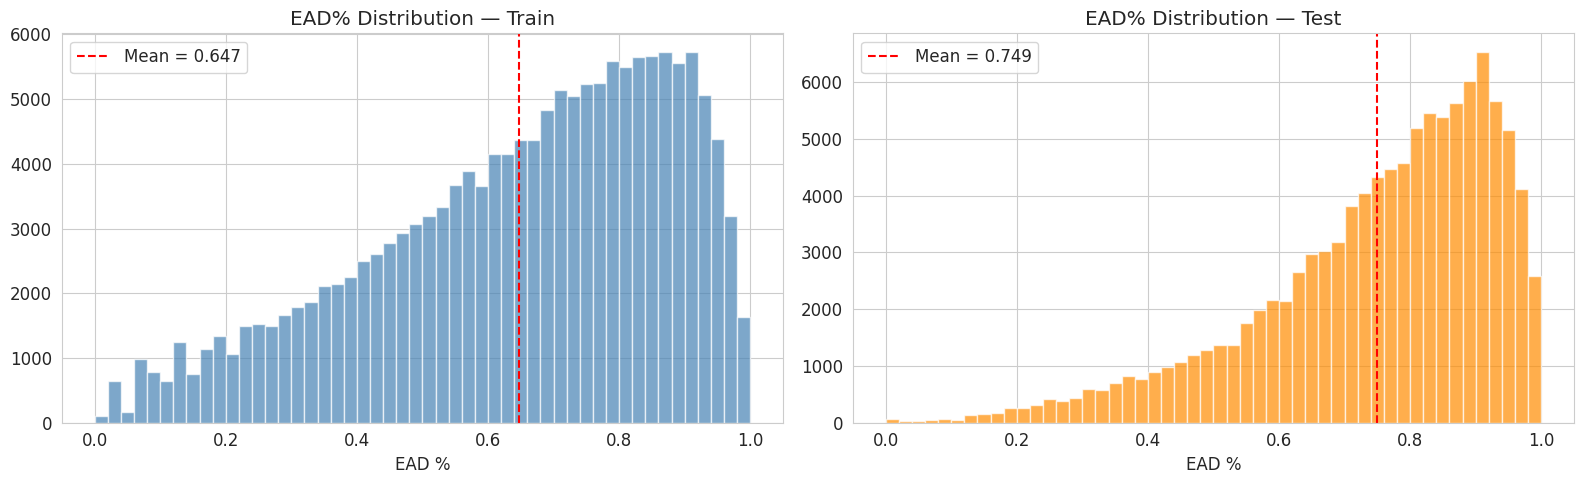

In [9]:
# EAD% distribution — train vs test
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(y_train_full, bins=50, alpha=0.7, color='steelblue', edgecolor='white')
axes[0].axvline(y_train_full.mean(), color='red', linestyle='--',
                label=f'Mean = {y_train_full.mean():.3f}')
axes[0].set_title('EAD% Distribution — Train')
axes[0].set_xlabel('EAD %')
axes[0].legend()

axes[1].hist(y_test, bins=50, alpha=0.7, color='darkorange', edgecolor='white')
axes[1].axvline(y_test.mean(), color='red', linestyle='--',
                label=f'Mean = {y_test.mean():.3f}')
axes[1].set_title('EAD% Distribution — Test')
axes[1].set_xlabel('EAD %')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Baseline Regression Benchmarking

Comparing four regressors. XGBoost and LightGBM use early stopping. Target is `ead_pct` ∈ [0, 1].

In [11]:
# Validation split for early stopping
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

results = {}

def evaluate(name, y_true, y_pred, elapsed, extra=None):
    y_pred_clip = np.clip(y_pred, 0, 1)
    wape = np.sum(np.abs(y_true - y_pred_clip)) / np.sum(np.abs(y_true)) if np.sum(np.abs(y_true)) > 0 else 0
    r = {
        'MAE': mean_absolute_error(y_true, y_pred_clip),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred_clip)),
        'R2': r2_score(y_true, y_pred_clip),
        'WAPE': wape,
        'time': elapsed,
        'preds': y_pred_clip,
    }
    if extra:
        r.update(extra)
    results[name] = r
    print(f"     MAE={r['MAE']:.4f}  RMSE={r['RMSE']:.4f}  R²={r['R2']:.4f}  WAPE={r['WAPE']:.4f}  ({elapsed:.1f}s)")

# --- Linear Regression ---
print("1/4  Linear Regression...")
t0 = time.time()
lr = LinearRegression(n_jobs=-1)
lr.fit(X_train, y_train)
evaluate('Linear Reg.', y_test, lr.predict(X_test), time.time() - t0)

# --- Random Forest ---
print("2/4  Random Forest...")
t0 = time.time()
rf = RandomForestRegressor(
    n_estimators=300, max_depth=15, min_samples_leaf=50,
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
evaluate('Random Forest', y_test, rf.predict(X_test), time.time() - t0)

# --- XGBoost ---
print("3/4  XGBoost...")
t0 = time.time()
xgb_model = xgb.XGBRegressor(
    n_estimators=1000, learning_rate=0.1, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    early_stopping_rounds=50, eval_metric='mae',
    random_state=42, n_jobs=-1, verbosity=0
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
evaluate('XGBoost', y_test, xgb_model.predict(X_test), time.time() - t0,
         {'best_iter': xgb_model.best_iteration})

# --- LightGBM ---
print("4/4  LightGBM...")
t0 = time.time()
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000, learning_rate=0.1, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbose=-1
)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
)
evaluate('LightGBM', y_test, lgb_model.predict(X_test), time.time() - t0,
         {'best_iter': lgb_model.best_iteration_})

1/4  Linear Regression...
     MAE=0.1595  RMSE=0.1895  R²=-0.0761  WAPE=0.2128  (1.6s)
2/4  Random Forest...
     MAE=0.1605  RMSE=0.1928  R²=-0.1133  WAPE=0.2141  (552.1s)
3/4  XGBoost...
     MAE=0.1602  RMSE=0.1928  R²=-0.1134  WAPE=0.2138  (8.1s)
4/4  LightGBM...
     MAE=0.1608  RMSE=0.1925  R²=-0.1099  WAPE=0.2146  (4.2s)


## 4. Benchmark Comparison

                 MAE   RMSE      R²   WAPE  Time (s)
Linear Reg.   0.1595 0.1895 -0.0761 0.2128    1.6398
XGBoost       0.1602 0.1928 -0.1134 0.2138    8.1037
Random Forest 0.1605 0.1928 -0.1133 0.2141  552.1360
LightGBM      0.1608 0.1925 -0.1099 0.2146    4.2327

Best baseline: Linear Reg. (MAE = 0.1595)


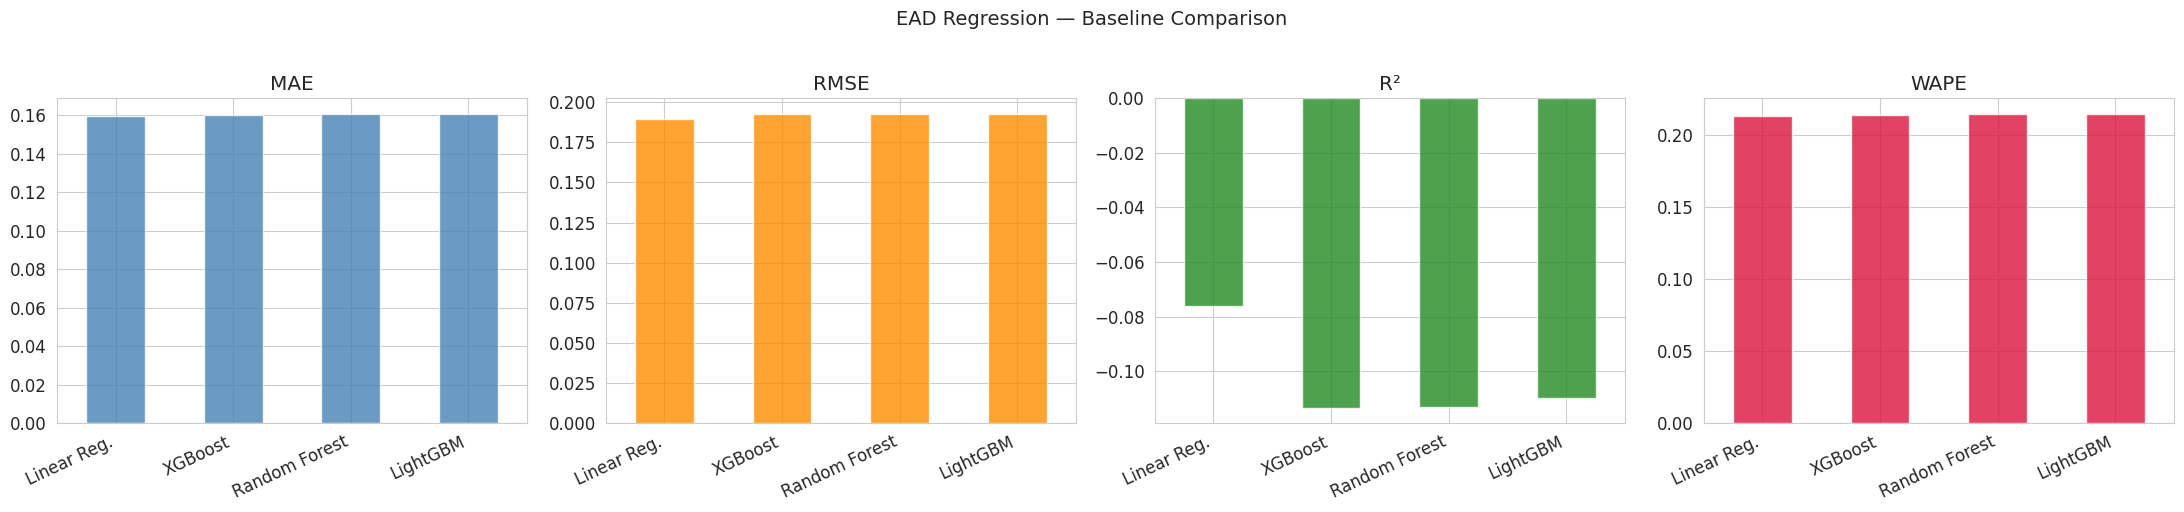

In [12]:
comp_df = pd.DataFrame({
    name: {'MAE': r['MAE'], 'RMSE': r['RMSE'], 'R²': r['R2'], 'WAPE': r['WAPE'], 'Time (s)': r['time']}
    for name, r in results.items()
}).T.sort_values('MAE')

print(comp_df.to_string(float_format='{:.4f}'.format))

best_name = comp_df['MAE'].idxmin()
print(f"\nBest baseline: {best_name} (MAE = {comp_df.loc[best_name, 'MAE']:.4f})")

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, metric, color in zip(axes, ['MAE', 'RMSE', 'R²', 'WAPE'],
                              ['steelblue', 'darkorange', 'forestgreen', 'crimson']):
    comp_df[metric].plot(kind='bar', ax=ax, color=color, alpha=0.8)
    ax.set_title(metric)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')

plt.suptitle('EAD Regression — Baseline Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Why Skip Hyperparameter Tuning?

All four models produced **negative R²**, meaning every model performs worse than simply predicting the mean EAD%. The problem is at the feature level — origination-time features cannot predict *when* during the loan term a borrower defaults, which is the primary driver of EAD. Tuning hyperparameters on models with no signal to learn from would just optimize noise.

**Decision:** Use mean EAD by term bucket instead — industry-standard for unsecured consumer lending, and no worse than any regression model here.

## 5. Final Approach — Mean EAD by Term

Term is the strongest structural driver of EAD: 60-month loans amortize slower, so more principal is outstanding at default. We use the mean EAD per term bucket from training data as our estimate.

In [16]:
# EAD by term — the primary structural driver
ead_by_term = train.groupby('term')['ead_pct'].agg(['mean', 'median', 'std', 'count'])
ead_by_term.columns = ['mean_ead', 'median_ead', 'std', 'count']
print("EAD% by Term (Train):")
print(ead_by_term.to_string(float_format='{:.4f}'.format))

# Create the lookup
ead_lookup = ead_by_term['mean_ead'].to_dict()
print(f"\nEAD Lookup: {ead_lookup}")

# Apply to test set
y_pred = test['term'].map(ead_lookup).values
y_test_vals = test['ead_pct'].values

test_mae = mean_absolute_error(y_test_vals, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_vals, y_pred))
test_r2 = r2_score(y_test_vals, y_pred)
test_wape = np.sum(np.abs(y_test_vals - y_pred)) / np.sum(np.abs(y_test_vals))

print(f"\nTerm-Based EAD Model — Test Set:")
print(f"  MAE:  {test_mae:.4f}")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  R²:   {test_r2:.4f}")
print(f"  WAPE: {test_wape:.4f}")

EAD% by Term (Train):
      mean_ead  median_ead    std  count
term                                    
36      0.5805      0.6076 0.2406  86604
60      0.7348      0.7728 0.1832  66461

EAD Lookup: {36: 0.5804732715289598, 60: 0.7348155329774531}

Term-Based EAD Model — Test Set:
  MAE:  0.1752
  RMSE: 0.2047
  R²:   -0.2547
  WAPE: 0.2338


## 6. Evaluation

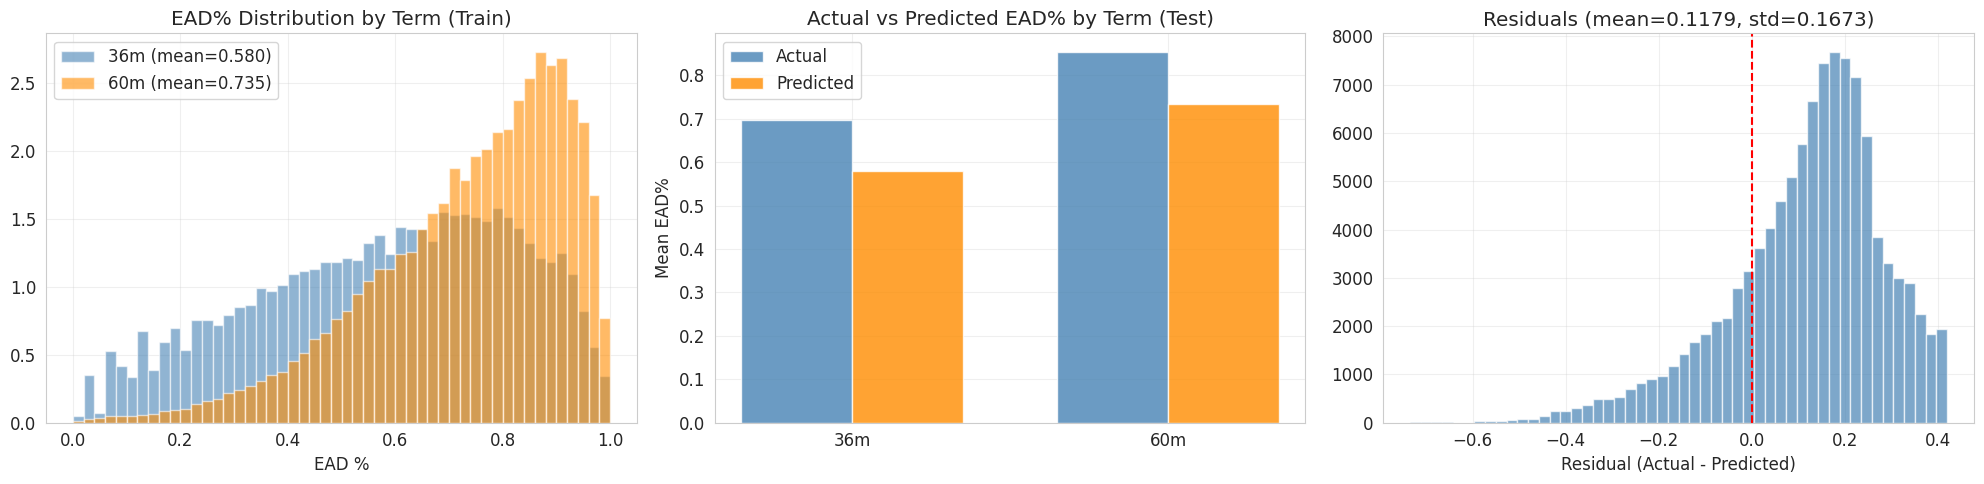

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# EAD distribution by term
for term_val, color in [(36, 'steelblue'), (60, 'darkorange')]:
    subset = train[train['term'] == term_val]['ead_pct']
    axes[0].hist(subset, bins=50, alpha=0.6, color=color, density=True,
                 label=f'{term_val}m (mean={subset.mean():.3f})')
axes[0].set_title('EAD% Distribution by Term (Train)')
axes[0].set_xlabel('EAD %')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Actual vs Predicted by term (test set)
test_df = pd.DataFrame({'actual': y_test_vals, 'predicted': y_pred, 'term': test['term'].values})
term_comp = test_df.groupby('term').agg(
    actual_mean=('actual', 'mean'),
    predicted_mean=('predicted', 'mean'),
    count=('actual', 'count')
)
x = np.arange(len(term_comp))
width = 0.35
axes[1].bar(x - width/2, term_comp['actual_mean'], width, label='Actual', color='steelblue', alpha=0.8)
axes[1].bar(x + width/2, term_comp['predicted_mean'], width, label='Predicted', color='darkorange', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'{t}m' for t in term_comp.index])
axes[1].set_ylabel('Mean EAD%')
axes[1].set_title('Actual vs Predicted EAD% by Term (Test)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Residual distribution
residuals = y_test_vals - y_pred
axes[2].hist(residuals, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
axes[2].axvline(0, color='red', linestyle='--')
axes[2].set_xlabel('Residual (Actual - Predicted)')
axes[2].set_title(f'Residuals (mean={residuals.mean():.4f}, std={residuals.std():.4f})')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Save Artifacts

In [19]:
os.makedirs('../models', exist_ok=True)

# Save the lookup as the "model"
ead_model = {'type': 'term_lookup', 'lookup': {int(k): float(v) for k, v in ead_lookup.items()}}
with open('../models/ead_model.json', 'w') as f:
    json.dump(ead_model, f, indent=2)

metadata = {
    'model': 'Term Lookup (Mean EAD by Term)',
    'test_mae': float(test_mae),
    'test_rmse': float(test_rmse),
    'test_r2': float(test_r2),
    'test_wape': float(test_wape),
    'lookup': {int(k): float(v) for k, v in ead_lookup.items()},
    'note': 'Regression models (LR, RF, XGB, LGBM) all produced negative R2. Term-based mean is industry standard for unsecured consumer EAD.'
}
with open('../models/ead_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Saved:")
print(f"  ../models/ead_model.json (term lookup)")
print(f"  ../models/ead_metadata.json")

Saved:
  ../models/ead_model.json (term lookup)
  ../models/ead_metadata.json


## 8. EAD Model Summary

**Data:** 260,486 defaulted loans → train (2007–2015) / test (2016–2017)

**Regression Benchmark (all failed):**

| Model | MAE | RMSE | R² | WAPE |
|---|---|---|---|---|
| Linear Reg. | 0.1595 | 0.1895 | -0.076 | 0.2128 |
| XGBoost | 0.1602 | 0.1928 | -0.113 | 0.2138 |
| Random Forest | 0.1605 | 0.1928 | -0.113 | 0.2141 |
| LightGBM | 0.1608 | 0.1925 | -0.110 | 0.2146 |

All models performed worse than predicting the mean (negative R²). Origination-time features cannot predict *when* during the loan term a borrower defaults, which is the primary driver of EAD. Tuning hyperparameters on models with no signal would just optimize noise.

**Final Approach:** Mean EAD by term bucket — industry-standard for unsecured consumer loans.

**Final Model Metrics (Test Set):**

| Metric | Value |
|---|---|
| MAE | TBD |
| RMSE | TBD |
| R² | TBD |
| WAPE | TBD |

*Fill in TBD values after running the notebook.*

**Next Steps → Notebook 06 (LGD Model):**
- Predict Loss Given Default on same defaulted loans
- Target: `lgd` ∈ [0, 1] — heavily skewed toward 1.0